# Real Estate Investment Analysis: Predicting Housing Prices in King County

**Author:** Zaara Shaikh<br>
**Project Type:** Predictive Modeling & Data Analysis<br>
**Tools:** Python (Pandas, NumPy, Scikit-Learn), Seaborn, Matplotlib

## Business Scenario
As a hypothetical analyst for a Real Estate Investment Trust (REIT), I have been tasked with determining the market price of residential properties in King County, USA (including Seattle). The goal is to build a predictive model that can accurately estimate housing prices based on features such as square footage, location, and condition, enabling more informed investment decisions.

## Objectives
* **Data Wrangling:** Clean and preprocess raw housing data (handling missing values, converting types).
* **Exploratory Data Analysis (EDA):** Identify key correlations between property features and market value.
* **Model Development:** Construct and evaluate various regression models (Linear, Ridge, Polynomial) to optimize prediction accuracy ($R^2$).

# About the Dataset

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015. It was taken from [here](https://www.kaggle.com/harlfoxem/housesalesprediction?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-wwwcourseraorg-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01). It was also slightly modified for the purposes of this course. 


| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | A notation for a house                                                                                      |
| date          | Date house was sold                                                                                         |
| price         | Price is prediction target                                                                                  |
| bedrooms      | Number of bedrooms                                                                                          |
| bathrooms     | Number of bathrooms                                                                                         |
| sqft_living   | Square footage of the home                                                                                  |
| sqft_lot      | Square footage of the lot                                                                                   |
| floors        | Total floors (levels) in house                                                                              |
| waterfront    | House which has a view to a waterfront                                                                      |
| view          | Has been viewed                                                                                             |
| condition     | How good the condition is overall                                                                           |
| grade         | overall grade given to the housing unit, based on King County grading system                                |
| sqft_above    | Square footage of house apart from basement                                                                 |
| sqft_basement | Square footage of the basement                                                                              |
| yr_built      | Built Year                                                                                                  |
| yr_renovated  | Year when house was renovated                                                                               |
| zipcode       | Zip code                                                                                                    |
| lat           | Latitude coordinate                                                                                         |
| long          | Longitude coordinate                                                                                        |
| sqft_living15 | Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area |
| sqft_lot15    | LotSize area in 2015(implies-- some renovations)                                                            |


### **Import the required libraries**


In [1]:
!pip install pandas numpy seaborn matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [3]:
!pip install -U scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
#import piplite
#await piplite.install('seaborn')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
%matplotlib inline

### Importing Data Sets


In [5]:
import requests

async def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)

In [6]:
filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
await download(filepath, "housing.csv")
file_name="housing.csv"

In [7]:
df = pd.read_csv(file_name)

In [8]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Question 1: Data Type Analysis & Statistical Summary

In [9]:
df.dtypes  # analyzing the datatypes of each column

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [10]:
df.describe() #statistical summary of DataFrame

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Question 2: Data Wrangling: Dropping Irrelevant Features

In [11]:
# Feature Selection & Cleaning
# The 'id' and 'Unnamed: 0' columns are unique identifiers/artifacts that do not
# hold predictive value for housing prices. We drop them to prevent noise.
df.drop(columns=['id','Unnamed: 0'], inplace = True)
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [12]:
# counting number of NaN values in bedrooms and bathrooms
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 13
number of NaN values for the column bathrooms : 10


In [13]:
# replacing the missing values of the column 'bedrooms' with the mean of the column.
mean=df['bedrooms'].mean()
df['bedrooms'].replace(np.nan,mean, inplace=True)

In [14]:
# replacing the missing values of the column 'bathrooms' with the mean of the column.
mean=df['bathrooms'].mean()
df['bathrooms'].replace(np.nan,mean, inplace=True)

In [15]:
#checking if the replacement was successfull
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


### Question 3: Feature Engineering: Analyzing Floor Counts

In [16]:
# Distribution Analysis: Floors
# We examine the frequency distribution of houses based on the number of floors
# to understand the composition of the housing stock.
df['floors'].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


### Question 4: Outlier Detection: Waterfront Impact on Price

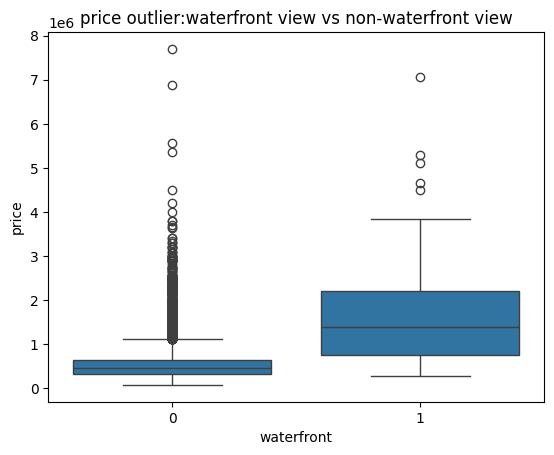

In [17]:
# Price Distribution Analysis: Waterfront Impact
# We use a boxplot to visually compare price distributions between houses with
# and without a waterfront view. This helps identify price premiums and potential outliers.
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('price outlier:waterfront view vs non-waterfront view')
plt.show()

### Question 5: Correlation Analysis: Living Area vs. Price

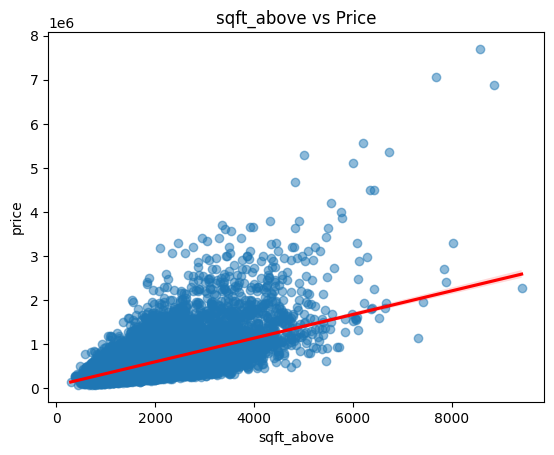

In [18]:
# Correlation Check: Sqft Above Ground vs. Price
# We use a regression plot to visualize the strength and direction of the linear relationship
# between square footage (above ground) and the target variable (price).
sns.regplot(x='sqft_above', y='price', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('sqft_above vs Price')
plt.show()

In [19]:
# using corr() to find the feature other than price that is most correlated with price.
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()['price'].sort_values()

zipcode         -0.053203
long             0.021626
condition        0.036362
yr_built         0.054012
sqft_lot15       0.082447
sqft_lot         0.089661
yr_renovated     0.126434
floors           0.256794
waterfront       0.266369
lat              0.307003
bedrooms         0.308797
sqft_basement    0.323816
view             0.397293
bathrooms        0.525738
sqft_living15    0.585379
sqft_above       0.605567
grade            0.667434
sqft_living      0.702035
price            1.000000
Name: price, dtype: float64

In [20]:
# Feature Selection: Geographic Correlation
# We test the correlation between 'longitude' and 'price' using a simple linear regression.
# This serves as a preliminary check to see if location coordinates alone are strong price predictors.

X = df[['long']] # Longitude feature
Y = df['price']  # Target variable

lm = LinearRegression()
lm.fit(X, Y)

# The low R^2 score indicates that longitude alone is a poor predictor of price
r2_long = lm.score(X, Y)
print(f"Longitude Regression R^2: {r2_long}")

Longitude Regression R^2: 0.0004676943014898516


### Question  6: Base Model: Simple Linear Regression

In [21]:
# Base Model: Simple Linear Regression (Living Area)
# We fit a linear regression model using 'sqft_living' as the sole predictor.
# This establishes a performance baseline (R^2) to compare against more complex models later.

X = df[['sqft_living']]
Y = df['price']

lm = LinearRegression()
lm.fit(X, Y)

# Calculate the R^2 score to evaluate the model's explanatory power
r2_living = lm.score(X, Y)
print(f"Living Area Regression R^2: {r2_living}")

Living Area Regression R^2: 0.4928532179037931


### Question 7: Multiple Linear Regression (MLR)

In [22]:
# Advanced Model: Multiple Linear Regression
# We expand our model to include structural (bedrooms, floors) and locational (lat, view)
# features to capture more variance in the housing prices.

features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view",
            "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]

X = df[features]
Y = df['price']

lm.fit(X, Y)

# Evaluating the improvement in R^2 compared to the simple model
r2_multiple = lm.score(X, Y)
print(f"Multiple Regression R^2: {r2_multiple}")

Multiple Regression R^2: 0.6576951666037499


### Question 8: Pipeline Construction & Scaling

In [23]:
# Pipeline Creation & Model Fitting
# We construct a pipeline to streamline the machine learning workflow.
Input = [('scale', StandardScaler()),                            #Normalizes the data so features are on the same scale.
         ('polynomial', PolynomialFeatures(include_bias=False)), #Generates polynomial features to capture non-linear relationships.
         ('model', LinearRegression())]                          #The final estimator that fits the model to the data.

# Initialize the pipeline object with the defined steps
pipe = Pipeline(Input)

# Define features and target variable
X = df[features]
Y = df['price']

# Fit the pipeline to the dataset and calculate the R^2 score
pipe.fit(X, Y)
r2_score = pipe.score(X, Y)

print(f"Pipeline R^2 value: {r2_score}")

Pipeline R^2 value: 0.7513408515988733


## Phase 2: Model Evaluation & Data Splitting

In [24]:
# Import the necessary modules:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
print("done")

done


In [25]:
# We will split the data into training and testing sets:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]    
X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)
print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


### Question 9: Ridge Regression (Regularization)

In [26]:
# Regularization: Ridge Regression
# To mitigate potential overfitting on the training data, we apply Ridge Regression (L2 regularization).
# We set the regularization strength (alpha) to 0.1.

from sklearn.linear_model import Ridge

# Initialize Ridge model with alpha=0.1
RidgeModel = Ridge(alpha=0.1)

# Train the model on the training split
RidgeModel.fit(x_train, y_train)

# Evaluate accuracy on the test split
r2_ridge = RidgeModel.score(x_test, y_test)
print(f"Ridge Regression R^2: {r2_ridge}")

Ridge Regression R^2: 0.6478759163939111


### Question 10: Polynomial Regression & Model Refinement

In [27]:
# Refined Model: Polynomial Ridge Regression
# To improve accuracy while controlling overfitting, we combine a 2nd-degree polynomial
# transformation with Ridge regression (L2 regularization).

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Create a pipeline that first transforms features into 2nd-degree polynomials,
# then applies Ridge Regression with a regularization parameter (alpha) of 0.1
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=0.1))
])

# Fit the refined model on the training set
pipeline.fit(x_train, y_train)

# Evaluate the model's performance on the unseen test set
r2_refined = pipeline.score(x_test, y_test)

print(f"Polynomial Ridge Regression R^2: {r2_refined}")

Polynomial Ridge Regression R^2: 0.7002744282602154


## Conclusion & Key Findings

This analysis compared several regression techniques to predict housing prices. The progression of model accuracy ($R^2$ score) demonstrates the value of feature engineering and advanced modeling techniques.

### Model Performance Summary:
1.  **Simple Linear Regression:** $R^2 \approx 0.49$ (Using only `sqft_living`).
2.  **Multiple Linear Regression:** $R^2 \approx 0.66$ (Using all relevant features).
3.  **Polynomial Regression (Degree 2) + Ridge:** $R^2 \approx 0.70$.
4.  **Refined Pipeline (Scaling + Polynomial + Linear):** $R^2 \approx 0.75$.

### Business Insights:
* **Key Drivers:** Square footage (`sqft_living`) and overall grade (`grade`) showed the strongest positive correlation with price.
* **Waterfront Premium:** Properties with a waterfront view displayed a significantly wider price distribution and higher median value (as seen in the boxplot analysis).
* **Model Recommendation:** The Pipeline approach (Standard Scaling + Polynomial Features) yielded the most reliable predictions, explaining approximately **75% of the variance** in housing prices.